### 1.0 Installing dependencies

In [12]:
from networkx.algorithms.bipartite import color
!pip install torch==2.7.0 torchvision torchaudio --index-url https://download.pytorch.org/whl/cu126 -q
!pip install sam3 scikit-learn requests ipywidgets python-dotenv -q

### 1.1 Importing Libraries

In [2]:
from datasets import Dataset, DatasetDict, load_dataset, Image
from collections import defaultdict
from huggingface_hub import login
from PIL import Image, ImageDraw
import matplotlib.pyplot as plt
from dotenv import load_dotenv
from datetime import datetime
from pathlib import Path
from re import split

import hashlib
import random
import shutil
import math
import re
import os

### 1.2 Global Definitions

In [94]:
DATASET_ROOT_DIR = './datasets/work/'  # must end with /
DATASET_DIR = DATASET_ROOT_DIR + 'train_validation_test'
MODELS_DIRECTORY = './models/'
load_dotenv()

True

### 1.3 Global Settings

In [25]:
# login("TOKEN") # Keep commented if token loaded from .env file

Note: Environment variable`HF_TOKEN` is set and is the current active token independently from the token you've just configured.


### 1.4 Global Structure

In [95]:
dataset_structure = {
    "path": "",
    "name": "",
    "classes": {
        0: "drone",
        1: "non-drone"
    },
    "images": [],
    "labels": []
}

### 1.5 Global Function Definitions

In [92]:
def list_files(directory: str, extensions: list, include_root_directory=False, recursive=False):
    matched_files = []

    # Ensure extensions is a tuple for endswith
    ext_tuple = tuple(extensions) if isinstance(extensions, list) else extensions

    if recursive:
        for root, _, files in os.walk(directory):
            for f in files:
                if f.endswith(ext_tuple):
                    matched_files.append(os.path.join(root, f) if include_root_directory else f)
    else:
        for f in os.listdir(directory):
            if f.endswith(ext_tuple) and os.path.isfile(os.path.join(directory, f)):
                matched_files.append(os.path.join(directory, f) if include_root_directory else f)

    return matched_files


def numeric_key(name):
    """Extract the first number from a filename for sorting."""
    nums = re.findall(r'\d+', name)
    return int(nums[0]) if nums else float('inf')


def sort_files_by_number(files: list):
    """
    Sort a list of filenames by the first number found in each name.

    Args:
        files (list): List of filenames (strings)

    Returns:
        list: Sorted list of filenames
    """
    return sorted(files, key=numeric_key)


def update_dataset_structure():
    dataset_structure["path"] = DATASET_DIR
    dataset_structure["name"] = DATASET_DIR.split("/")[-2]

    dataset_structure["images"] = sort_files_by_number(
        list_files(DATASET_DIR, [".jpg", ".jpeg", ".JPG", ".JPEG"], True)
    )
    dataset_structure["labels"] = sort_files_by_number(
        list_files(DATASET_DIR, [".txt"], True)
    )


def delete_files_in_dataset(files_to_delete: list):
    try:
        confirm = input("Files are going to be deleted. Type 'yes' to continue: ").strip().lower()
        if confirm != 'yes':
            print("Deletion aborted by user.")
            return

        for file in files_to_delete:
            if os.path.isfile(file):
                os.remove(file)
                print(f"Deleted: {file}")
            else:
                print(f"Warning: File does not exist: {file}")

    except KeyboardInterrupt:
        print("\nDeletion aborted by user (KeyboardInterrupt).")


def backup_dataset():
    dataset_path = dataset_structure.get("path", "")
    backup_dir = os.path.join("./datasets", ".backup")
    os.makedirs(backup_dir, exist_ok=True)

    now = datetime.now().strftime('%Y-%m-%d_%H-%M-%S')
    target_name = f"{dataset_structure["name"]}-{now}"
    target_path = os.path.join(backup_dir, target_name)

    # Copytree with ignoring to exclude the backup folder itself
    def ignore_backup(src, names):
        return {"backup"} if "backup" in names else set()

    shutil.copytree(dataset_path, target_path, ignore=ignore_backup)
    print(f"Backup created at: {target_path}")
    return str(target_path)

# 📂 2. Dataset

In [88]:
dataset = load_dataset("Hibou-Foundation/computer-vision")

### 2.2 Convert to Yolo

In [89]:
# Create folders
for split in ["train_validation_test"]:
    os.makedirs(f"{DATASET_ROOT_DIR}/{split}", exist_ok=True)


def export_to_yolo(ds, split_name):
    for idx, sample in enumerate(ds):
        image = sample["image"]  # already a PIL.Image
        label = sample["raw_label"]  # already YOLO format [[class, cx, cy, w, h], ...]

        # Save image
        img_path = f"{DATASET_ROOT_DIR}/{split_name}/{idx}.jpg"
        image.save(img_path, quality=95)

        # Save labels
        lbl_path = f"{DATASET_ROOT_DIR}/{split_name}/{idx}.txt"
        with open(lbl_path, "w") as f:
            f.write(label)


# Run export
split_mapping = {"train_validation_test": "train_validation_test"}
for hf_split, folder_name in split_mapping.items():
    export_to_yolo(dataset[hf_split], folder_name)

### 2.2 Data Structure Check

#### Directory path validation

In [96]:
update_dataset_structure()

print(f"Dataset path: {DATASET_DIR}")
print(f"Dataset name: {dataset_structure['name']}\n")

print(f"Number of images : {len(dataset_structure['images'])}")
print(f"Number of labels : {len(dataset_structure['labels'])}")

Dataset path: ./datasets/work/train_validation_test
Dataset name: work

Number of images : 4614
Number of labels : 4614


#### Duplicate files

Check for duplicate images and labels.

In [97]:
duplicate_paths_to_check = [
    dataset_structure["images"],
    dataset_structure["labels"],
]


def sha3_file(path, chunk_size=8192):
    hash_sha3 = hashlib.sha3_256()
    with open(path, "rb") as f:
        for chunk in iter(lambda: f.read(chunk_size), b""):
            hash_sha3.update(chunk)
    return hash_sha3.hexdigest()


duplicates_array = []

for path in duplicate_paths_to_check:

    # Build list of (hash, path)
    pairs = [
        (sha3_file(f), f)
        for f in path
    ]

    # Group paths by hash
    hash_map = defaultdict(list)
    for h, p in pairs:
        hash_map[h].append(p)

    # Extract only duplicates
    duplicates = {h: paths for h, paths in hash_map.items() if len(paths) > 1}
    duplicates_array.append(duplicates)

    # Print results
    if duplicates:
        print("Duplicate files found:")
        for h, paths in duplicates.items():
            print(f"Hash: {h}")
            for p in paths:
                print(f"  - {p}")
    else:
        print(f"No duplicate files found in the scanned directories.")

No duplicate files found in the scanned directories.
No duplicate files found in the scanned directories.


##### ⚠️Delete duplicate files ⚠️

Delete duplicate images and labels.

In [77]:
try:
    if input("Files are going to be deleted. Write yes to continue.") == 'yes':
        for duplicates in duplicates_array:
            for paths in duplicates.values():
                os.remove(paths[0])

except KeyboardInterrupt:
    print("Deletion aborted.")
finally:
    update_dataset_structure()

#### Check for non-valid txt files

In [98]:
empty_label_paths_to_check = [
    dataset_structure["labels"]
]

empty_label = []

for path_list in empty_label_paths_to_check:
    for p in path_list:

        with open(p, "r") as f:
            content = f.read()
            content = re.split(r"\s+", content)
            content_length = len(content)

            if content_length <= 4:
                empty_label.append([p, "Not enough elements in the label file."])
                continue

            if len(content) % 5 != 0:
                empty_label.append([p, "Label file is not divisible by 5 elements."])
                print(content)
                continue

            for i in range(0, content_length, 5):
                if not content[i].isdigit():
                    empty_label.append([p, "Label file contains non-numeric elements."])
                    continue

for e in empty_label:
    print(f"{e[0]}: {e[1]}")

print("Done")

Done


#### Check for orphelins txt file

In [99]:
orphans_duplicate_paths_to_check = [
    dataset_structure["labels"],
]

orphelins_label = []

for path_list in orphans_duplicate_paths_to_check:
    for p in path_list:

        root, _ = os.path.splitext(p)

        candidates = [
            root + ".jpg",
            root + ".JPG",
            root + ".jpeg",
            root + ".JPEG",
            root + ".png",
            root + ".PNG",
        ]

        if not any(os.path.isfile(c) for c in candidates):
            orphelins_label.append(p)
            print(f"TXT file {p} does not belong to any image.")
print("Done")

Done


##### ⚠️Delete orphelin labels files ⚠️

Delete labels that don't belong to any images.

In [38]:
delete_files_in_dataset(orphelins_label)

Deleted: ./datasets/birds/all/79.txt


#### Check for orphelins image file

In [100]:
orphans_images_paths_to_check = [
    dataset_structure["images"],
]

orphelins_images = []

for path_list in orphans_images_paths_to_check:
    for p in path_list:

        root, _ = os.path.splitext(p)

        candidates = [
            root + ".txt",
        ]

        if not any(os.path.isfile(c) for c in candidates):
            orphelins_images.append(p)
            print(f"TXT file {p} does not belong to any label.")
print("Done")

Done


##### ⚠️Delete orphelin labels files ⚠️

Delete images that don't belong to any labels.

In [ ]:
delete_files_in_dataset(orphelins_images)

#### Rename files

Rename images and labels from 0 to n images.

In [101]:
jpeg_extension = [".jpg", ".jpeg", ".JPG", ".JPEG"]

tmp = os.path.join(DATASET_ROOT_DIR, "tmp")


def numeric_key(name):
    nums = re.findall(r'\d+', name)
    return int(nums[0]) if nums else float('inf')


def collect_images(folder):
    return sorted(
        [f for f in os.listdir(folder) if f.endswith(tuple(jpeg_extension))],
        key=numeric_key
    )


def process(folder, start_i, out_dir):
    files = collect_images(folder)
    print(f"Processing {out_dir}...")

    if not os.path.exists(out_dir):
        os.mkdir(out_dir)

    for f in files:
        pass
        root, ext = os.path.splitext(f)

        # find real existing image
        image_path = None
        for e in jpeg_extension:
            p = os.path.join(folder, root + e)
            if os.path.isfile(p):
                image_path = p
                break

        if image_path is None:
            print("Missing image for:", f)
            continue

        label_path = os.path.join(folder, root + ".txt")
        if not os.path.isfile(label_path):
            os.rename(image_path, os.path.join(out_dir, f"{start_i}.jpg"))
            start_i += 1
            continue

        new_image = os.path.join(out_dir, f"{start_i}.jpg")
        new_label = os.path.join(out_dir, f"{start_i}.txt")

        # Move safely
        os.rename(image_path, new_image)
        os.rename(label_path, new_label)

        start_i += 1

    os.rmdir(folder)
    os.rename(out_dir, folder)

    return start_i


# === RUN ===
backup_dataset()

i = 0
i = process(DATASET_DIR, i, tmp + '_all')

update_dataset_structure()

print(f"DONE — All files renamed safely into {DATASET_ROOT_DIR}tmp_NAME")

Backup created at: ./datasets/.backup/work-2026-01-22_18-05-13
Processing ./datasets/work/tmp_all...
DONE — All files renamed safely into ./datasets/work/tmp_NAME


### Set labels

In [83]:
class_id_to_update = [
    dataset_structure["labels"],
]

try:
    if input("Files are going to be changed. Write yes to continue.") == 'yes':
        current_class_id = 0
        new_class_id = 1

        for path_list in class_id_to_update:
            for p in path_list:
                with open(p, "r") as f:
                    content = f.read()

                content = re.split(r"\s+", content)

                for i in range(0, len(content), 5):
                    if content[i] == str(current_class_id):
                        content[i] = str(new_class_id)

                # Rebuild content with newline after every 5 columns
                rows = [
                    " ".join(content[i:i + 5])
                    for i in range(0, len(content), 5)
                ]

                content = "\n".join(rows)

                with open(p, "w") as f:
                    f.write(content)

except KeyboardInterrupt:
    print("Change aborted.")

Change aborted.


In [ ]:
from sam3.model.sam3_image_processor import Sam3Processor
from sam3.visualization_utils import plot_results
from sam3 import build_sam3_image_model

In [ ]:
bpe_name = "bpe_simple_vocab_16e6.txt.gz"

##### Load model

In [ ]:
model = build_sam3_image_model(bpe_path=os.path.join(MODELS_DIRECTORY, bpe_name))
processor = Sam3Processor(model)

In [ ]:
sam_sample_image_path = f"datasets/new_dataset/training/633.jpg"
prompt = "drone"
confidence_threshold = 0.5

image = Image.open(sam_sample_image_path)
width, height = image.size
processor = Sam3Processor(model, confidence_threshold=confidence_threshold)
inference_state = processor.set_image(image)

processor.reset_all_prompts(inference_state)
inference_state = processor.set_text_prompt(state=inference_state, prompt=prompt)
img0 = Image.open(sam_sample_image_path)
plot_results(img0, inference_state)

##### Settings

In [ ]:
labelize_overwrite_label: bool = True
labelize_prompt: str = 'drone'
labelize_confidence_threshold: float = 0.62
labelize_drone_class = 0
labelize_output_label_file_directory = os.path.join(DATASET_ROOT_DIR, 'new_labels')
labelize_output_label_file_errors = os.path.join(labelize_output_label_file_directory, 'errors.txt')
labelize_output_label_file_success = os.path.join(labelize_output_label_file_directory, 'success.txt')

liberalizations_path = [
    dataset_structure["train_files_images"],
    dataset_structure["valid_files_images"],
]


In [ ]:
os.makedirs(labelize_output_label_file_directory, exist_ok=True)

image_failed_labelize = []

for paths in liberalizations_path:
    for image_path in paths:
        root, ext = os.path.splitext(image_path)
        root_label_name = root.split("/")[-1]
        current_label_path = root + ".txt"
        saved_label_path = os.path.join(labelize_output_label_file_directory, root_label_name) + ".txt"

        if os.path.isfile(current_label_path) and not labelize_overwrite_label:
            continue

        if os.path.isfile(saved_label_path) and not labelize_overwrite_label:
            continue

        # Load image
        image = Image.open(image_path)
        if image.mode != "RGB":
            with open(labelize_output_label_file_errors, "a") as f:
                image_failed_labelize.append(image_path)
                f.write(f"{image_path} is not RGB.\n")
            continue
        width, height = image.size

        # Run SAM3 processor
        processor = Sam3Processor(model, confidence_threshold=labelize_confidence_threshold)
        inference_state = processor.set_image(image)
        processor.reset_all_prompts(inference_state)
        inference_state = processor.set_text_prompt(state=inference_state, prompt=labelize_prompt)

        # --- Save YOLO labels ---
        bboxes = inference_state.get("boxes", None)  # fixed

        if bboxes is None or len(bboxes) == 0:
            # print(f"No detections for {image_path}")
            image_failed_labelize.append(image_path)
            with open(labelize_output_label_file_errors, "a") as f:
                f.write(f"No detections for {image_path}\n")
            continue

        yolo_lines = []
        for box in bboxes:
            x_min, y_min, x_max, y_max = box  # SAM3 gives XYXY

            # Convert to YOLO format
            bbox_width = x_max - x_min
            bbox_height = y_max - y_min

            cx = (x_min + bbox_width / 2) / width
            cy = (y_min + bbox_height / 2) / height

            nw = bbox_width / width
            nh = bbox_height / height

            yolo_lines.append(
                f"{labelize_drone_class} {cx:.6f} {cy:.6f} {nw:.6f} {nh:.6f}"
            )

        with open(saved_label_path, "w") as f:
            f.write("\n".join(yolo_lines))
        with open(labelize_output_label_file_success, "a") as f:
            f.write(f"Saved YOLO labels: {saved_label_path}\n")

    with open(labelize_output_label_file_success, 'r') as fp:
        nb_lines = len(fp.readlines())
        print(f"Successfully procedded files: {nb_lines} out of {len(paths)}")

In [ ]:
try:
    if input("Files are going to be deleted. Write yes to continue.") == 'yes':
        for image_path in image_failed_labelize:
            os.remove(image_path)
except KeyboardInterrupt:
    print("Deletion aborted.")

### 2.3 Check

Load N random images and show rectangles around the drones detected by SAM3.

In [106]:
def load_image_with_boxes(image_path, label_path):
    """Returns a PIL image with YOLO bounding boxes drawn."""
    img = Image.open(image_path).convert("RGB")
    draw = ImageDraw.Draw(img)

    colors = ["red", "blue", "green", "orange"]

    w, h = img.size

    if os.path.exists(label_path):
        with open(label_path, "r") as f:
            lines = f.readlines()

        for line in lines:
            cls, xc, yc, bw, bh = map(float, line.split())

            color = colors[int(cls)]

            # YOLO normalized → pixel coordinates
            x_center = xc * w
            y_center = yc * h
            box_width = bw * w
            box_height = bh * h

            x1 = x_center - box_width / 2
            y1 = y_center - box_height / 2
            x2 = x_center + box_width / 2
            y2 = y_center + box_height / 2


            draw.rectangle([x1, y1, x2, y2], outline=color, width=3)
            draw.text((x1, y1), f"{int(cls)}", fill="red")

    return img

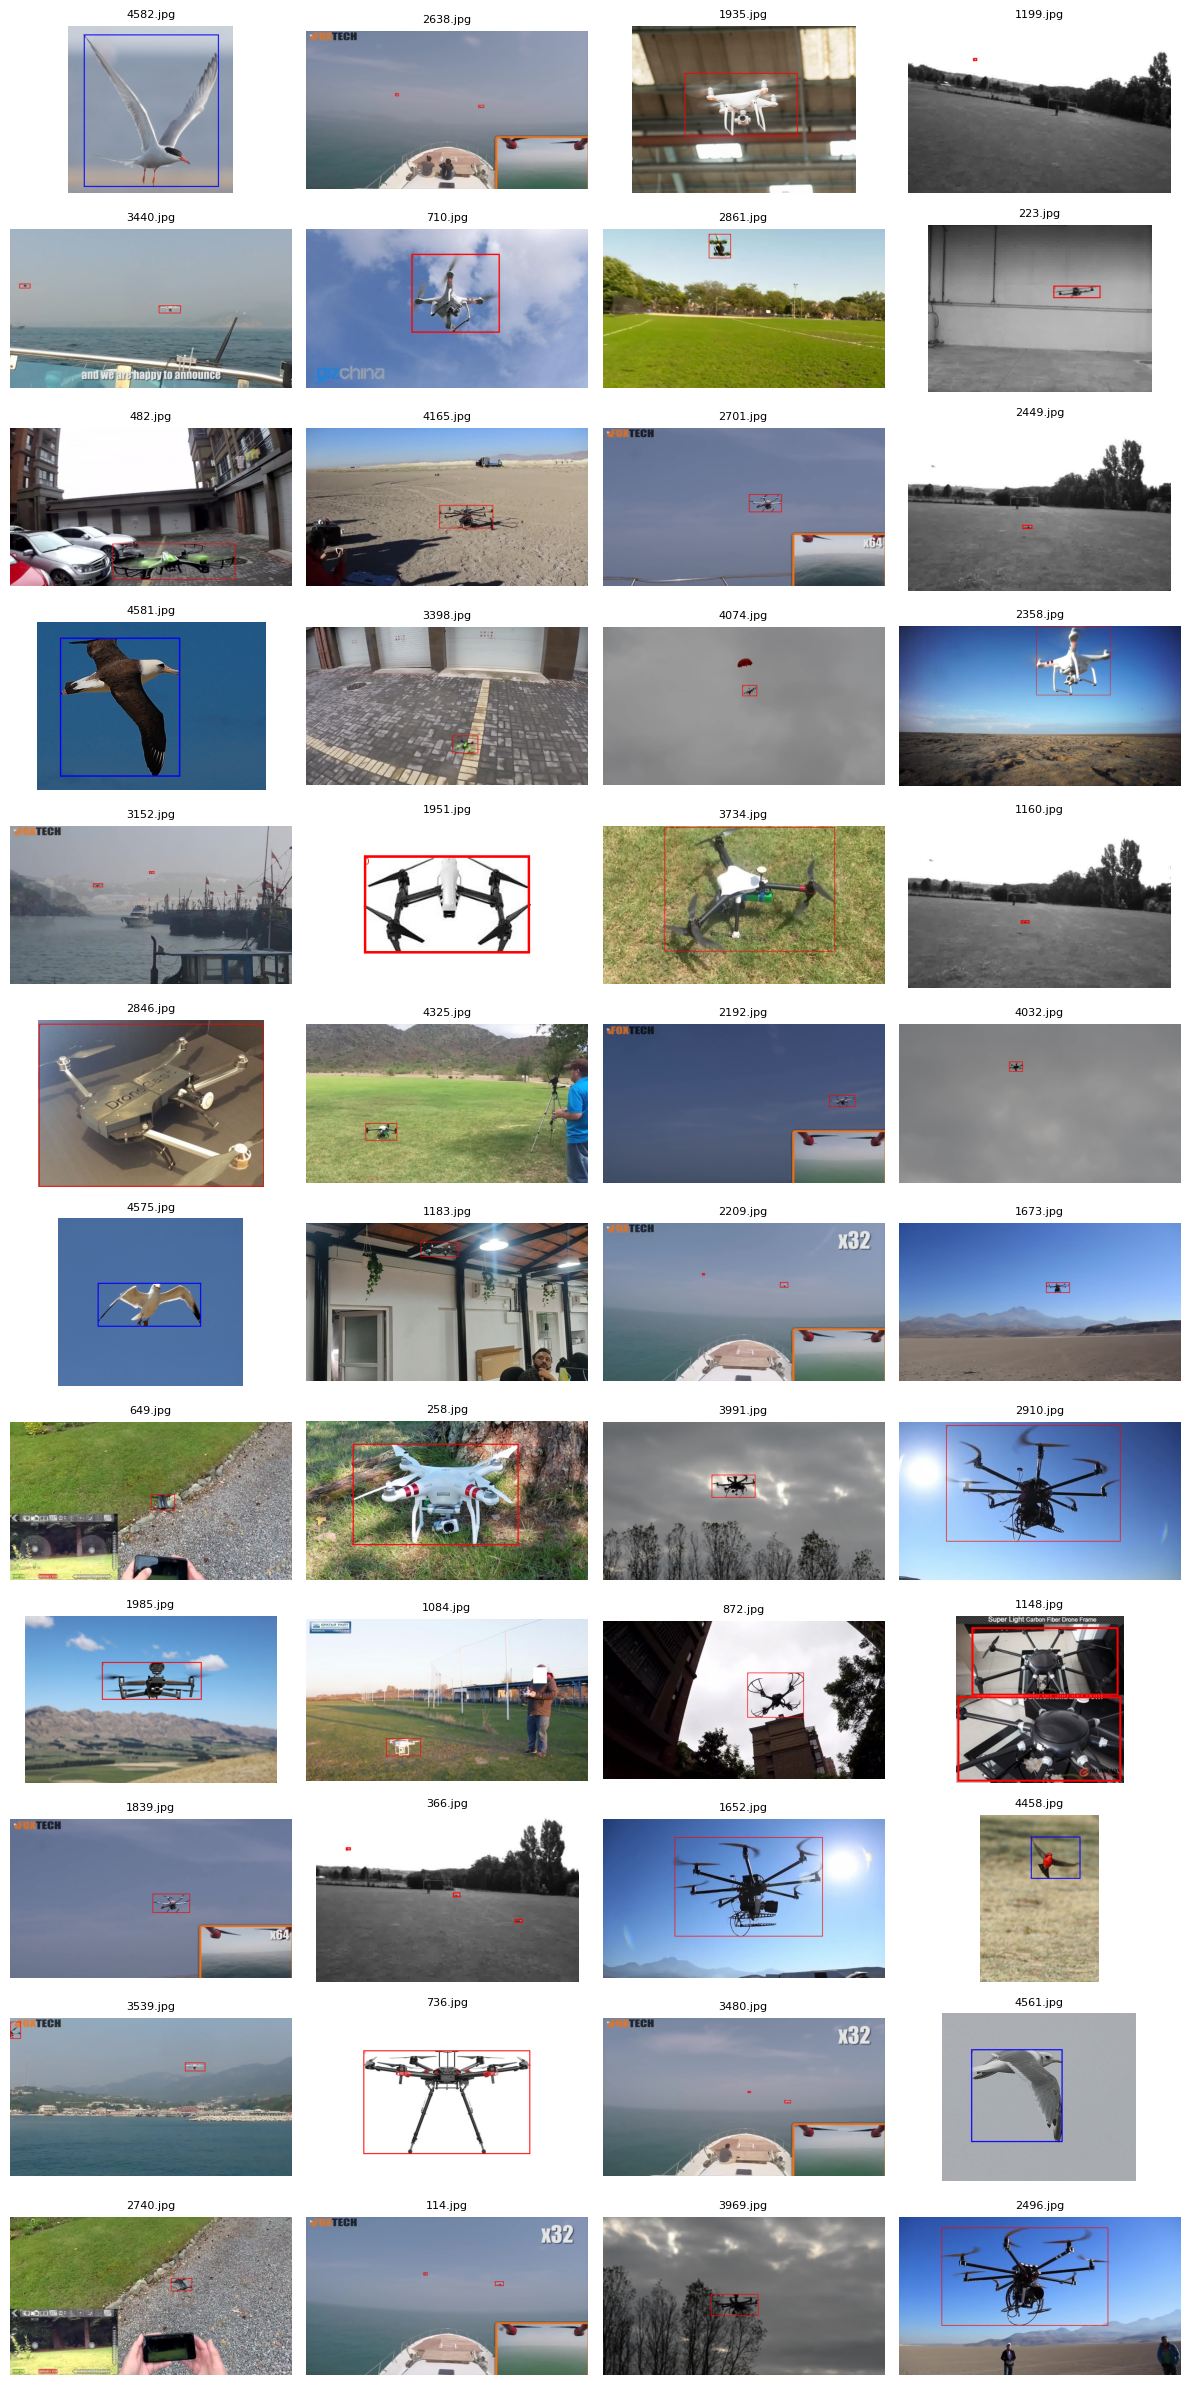

In [109]:
N = 48  # number of random samples
cols = 4

%matplotlib inline

# list all images
image_paths = [p for p in os.listdir(DATASET_DIR) if p.lower().endswith((".jpg", ".png"))]
sampled_images = random.sample(image_paths, min(N, len(image_paths)))

# -------- DISPLAY GRID -------- #

rows = math.ceil(len(sampled_images) / cols)

fig, axes = plt.subplots(rows, cols, figsize=(cols * 3, rows * 2))
axes = axes.flatten()

for ax, img_name in zip(axes, sampled_images):
    img_path = os.path.join(DATASET_DIR, img_name)
    label_path = os.path.join(DATASET_DIR, img_name.rsplit(".", 1)[0] + ".txt")

    img = load_image_with_boxes(img_path, label_path)

    ax.imshow(img)
    ax.axis("off")
    ax.set_title(img_name, fontsize=8)

# turn off unused axes
for ax in axes[len(sampled_images):]:
    ax.axis("off")

plt.tight_layout()
plt.show()

#### Upload

In [104]:
def load_split(image_dir: Path, label_dir: Path):
    data = []
    for img_path in image_dir.glob("*.jpg"):
        label_path = label_dir / f"{img_path.stem}.txt"
        with open(label_path) as f:
            label = str(f.read().strip())  # parse label as needed
        class_id = int(label.split()[0])
        class_name = dataset_structure["classes"][class_id]
        box = label.split()[1:]
        data.append({"image": Image.open(img_path), "class_id": class_id, "class_name": class_name, "box": box, "name": img_path.name, "raw_label": label})
    return Dataset.from_list(data)


# Paths
train_image_dir = Path(DATASET_DIR)
train_label_dir = Path(DATASET_DIR)

# Load datasets
train_dataset = load_split(train_image_dir, train_label_dir)

# Combine into DatasetDict
dataset = DatasetDict({
    "train_validation_test": train_dataset,
})

dataset

DatasetDict({
    train_validation_test: Dataset({
        features: ['image', 'class_id', 'class_name', 'box', 'name', 'raw_label'],
        num_rows: 4614
    })
})

In [105]:
dataset.push_to_hub("Hibou-Foundation/computer-vision")

Uploading the dataset shards:   0%|          | 0/2 [00:00<?, ? shards/s]

Map:   0%|          | 0/2307 [00:00<?, ? examples/s]

Creating parquet from Arrow format:   0%|          | 0/3 [00:00<?, ?ba/s]

Processing Files (0 / 0): |          |  0.00B /  0.00B            

New Data Upload: |          |  0.00B /  0.00B            

Map:   0%|          | 0/2307 [00:00<?, ? examples/s]

Creating parquet from Arrow format:   0%|          | 0/3 [00:00<?, ?ba/s]

Processing Files (0 / 0): |          |  0.00B /  0.00B            

New Data Upload: |          |  0.00B /  0.00B            

CommitInfo(commit_url='https://huggingface.co/datasets/Hibou-Foundation/computer-vision/commit/85c4188535a718ebc244716070fd77e8af2d4ae9', commit_message='Upload dataset', commit_description='', oid='85c4188535a718ebc244716070fd77e8af2d4ae9', pr_url=None, repo_url=RepoUrl('https://huggingface.co/datasets/Hibou-Foundation/computer-vision', endpoint='https://huggingface.co', repo_type='dataset', repo_id='Hibou-Foundation/computer-vision'), pr_revision=None, pr_num=None)